# E-Commerce Customer Churn Prediction

This notebook contains the complete end-to-end pipeline for predicting customer churn in an e-commerce setting.

**Sections:**
1. Data Loading
2. Exploratory Data Analysis (EDA)
3. Advanced Feature Engineering
4. Preprocessing (Missing Values, Encoding, Scaling, Train/Test Split)
5. Models (Logistic Regression, Random Forest, Gradient Boosting, XGBoost, DNN, LSTM, LightGBM, SVM, CatBoost)
6. Model Performance Summary
7. Conclusions
8. Streamlit Dashboard Export and Launch

---
## 1. Data Loading

In [45]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("E Commerce Dataset.csv")

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns\n")
print("First 5 rows:")
df.head()

Dataset loaded successfully!
Shape: 5,630 rows x 20 columns

First 5 rows:


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130


---
## 2. Exploratory Data Analysis (EDA)

In [46]:
print("--- Column types ---")
print(df.dtypes)

print("\n--- Missing values (%) ---")
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
print(missing_pct[missing_pct > 0].head(30))

TARGET_COL = "Churn"
print("\n--- Target distribution ---")
print(df[TARGET_COL].value_counts(dropna=False))
print(df[TARGET_COL].value_counts(normalize=True).rename("proportion"))

num_cols_all = df.select_dtypes(include=["number"]).columns.tolist()
print("\n--- Numeric summary (selected) ---")
print(df[num_cols_all].describe().T.head(20))

if TARGET_COL in num_cols_all:
    corr = df[num_cols_all].corr(numeric_only=True)[TARGET_COL].sort_values(ascending=False)
    print("\n--- Numeric correlations with churn (rough) ---")
    print(corr)

--- Column types ---
CustomerID                       int64
Churn                            int64
Tenure                         float64
PreferredLoginDevice            object
CityTier                         int64
WarehouseToHome                float64
PreferredPaymentMode            object
Gender                          object
HourSpendOnApp                 float64
NumberOfDeviceRegistered         int64
PreferedOrderCat                object
SatisfactionScore                int64
MaritalStatus                   object
NumberOfAddress                  int64
Complain                         int64
OrderAmountHikeFromlastYear    float64
CouponUsed                     float64
OrderCount                     float64
DaySinceLastOrder              float64
CashbackAmount                   int64
dtype: object

--- Missing values (%) ---
DaySinceLastOrder              5.452931
OrderAmountHikeFromlastYear    4.706927
Tenure                         4.689165
OrderCount                     4.5825

### 2.1 Numerical Feature Distributions

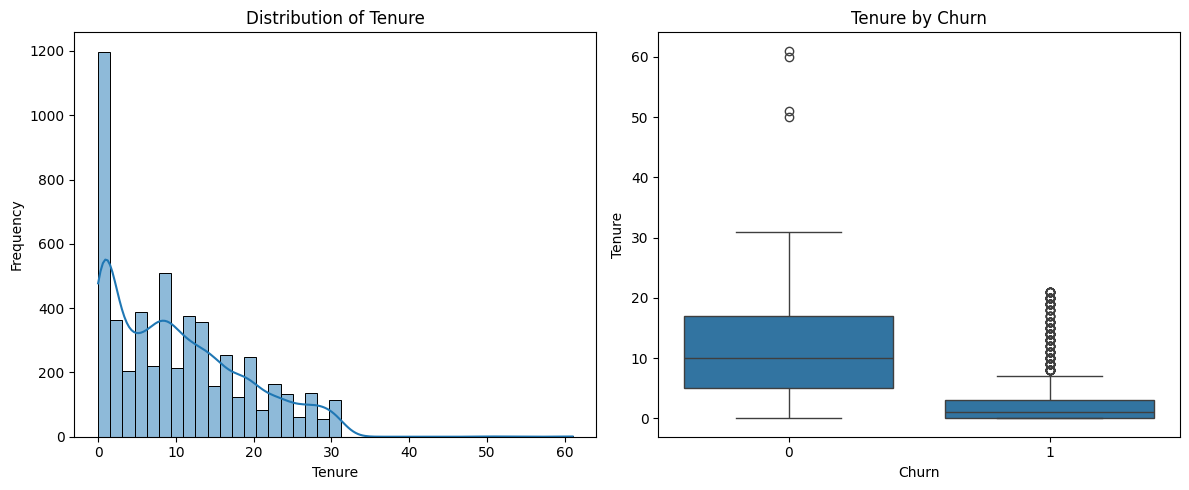

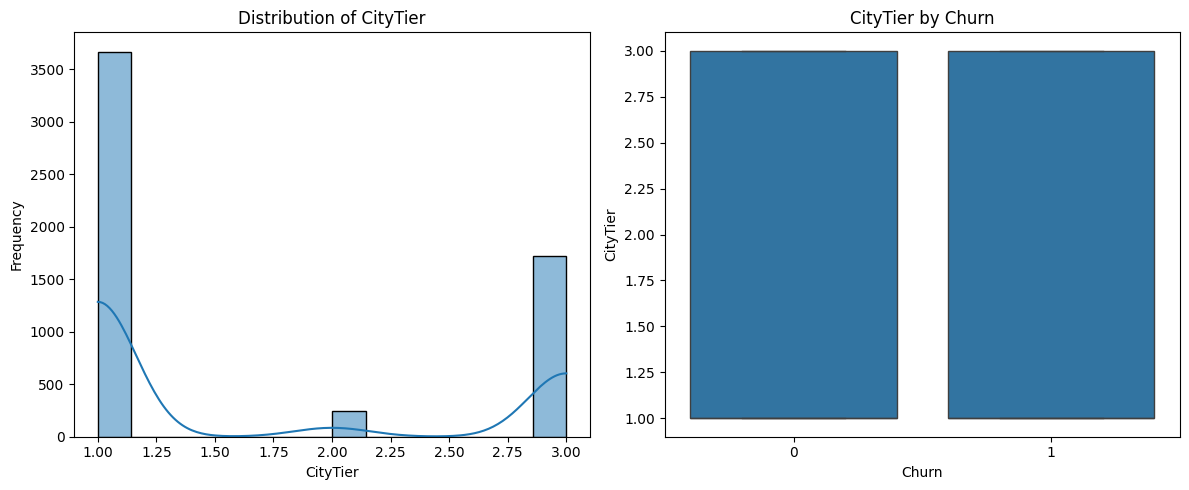

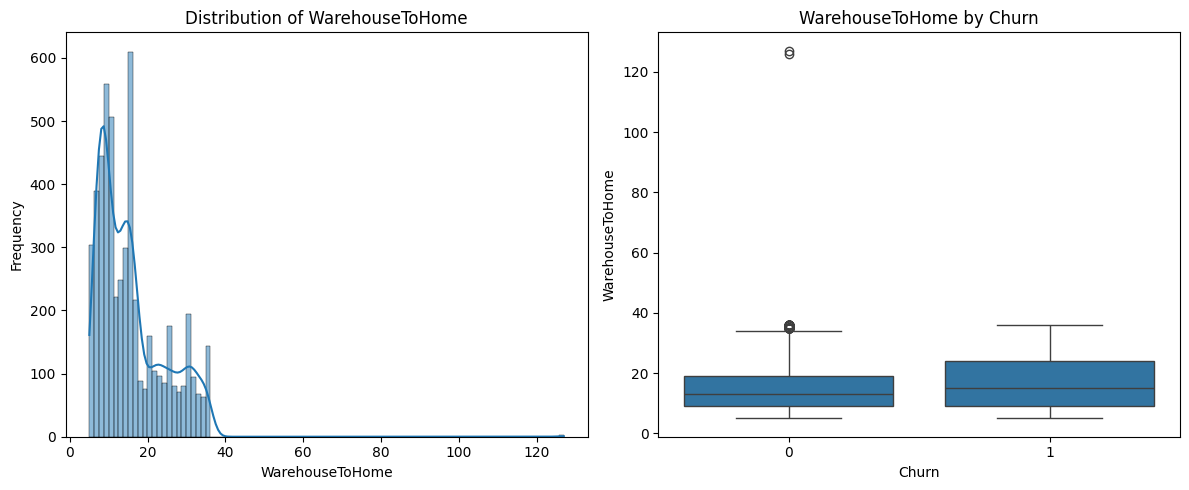

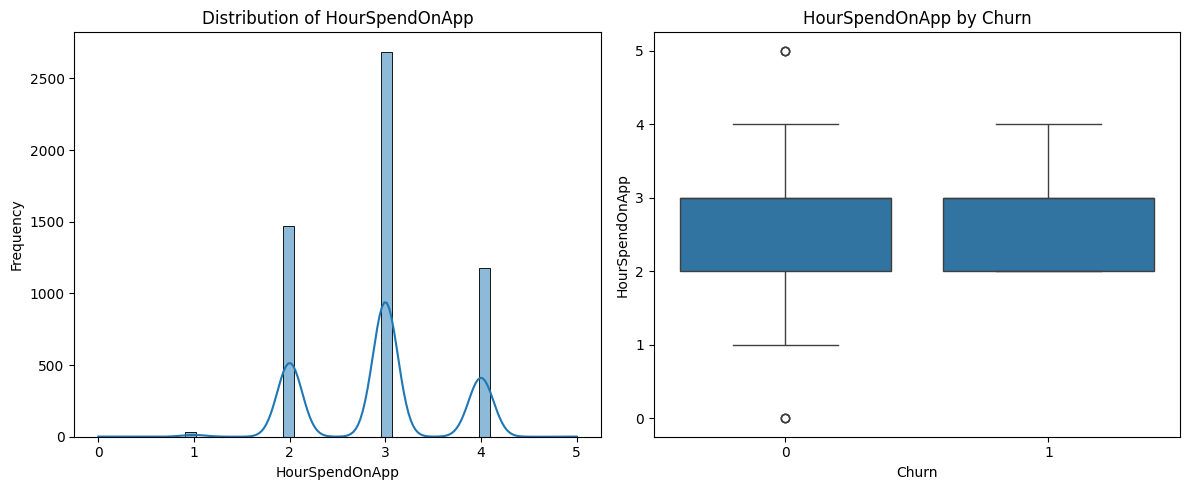

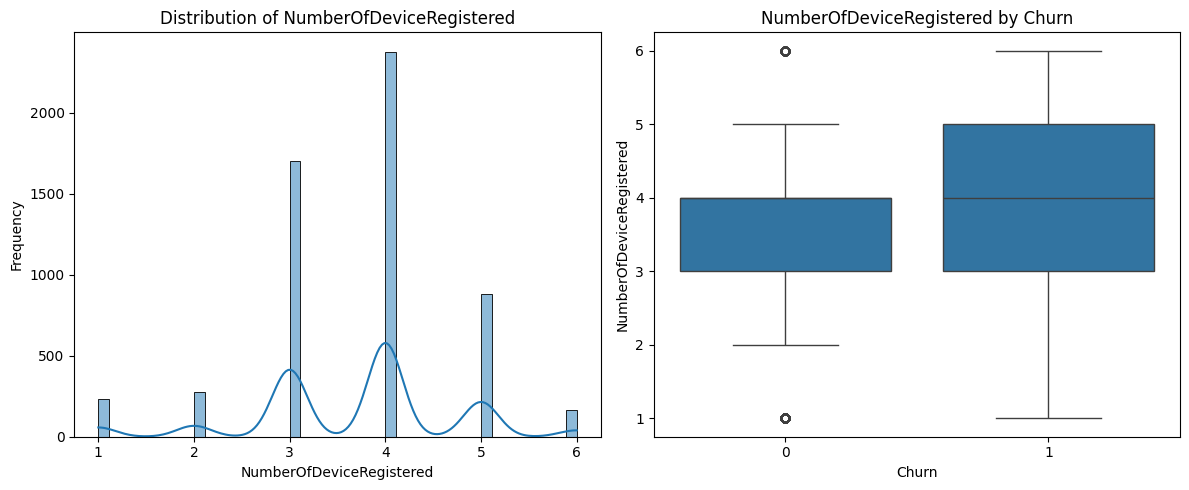

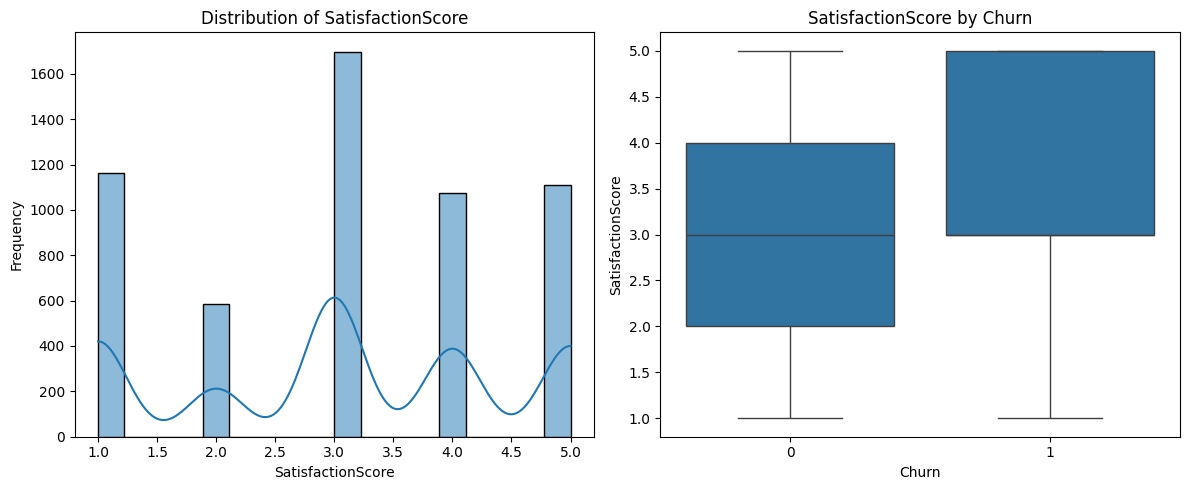

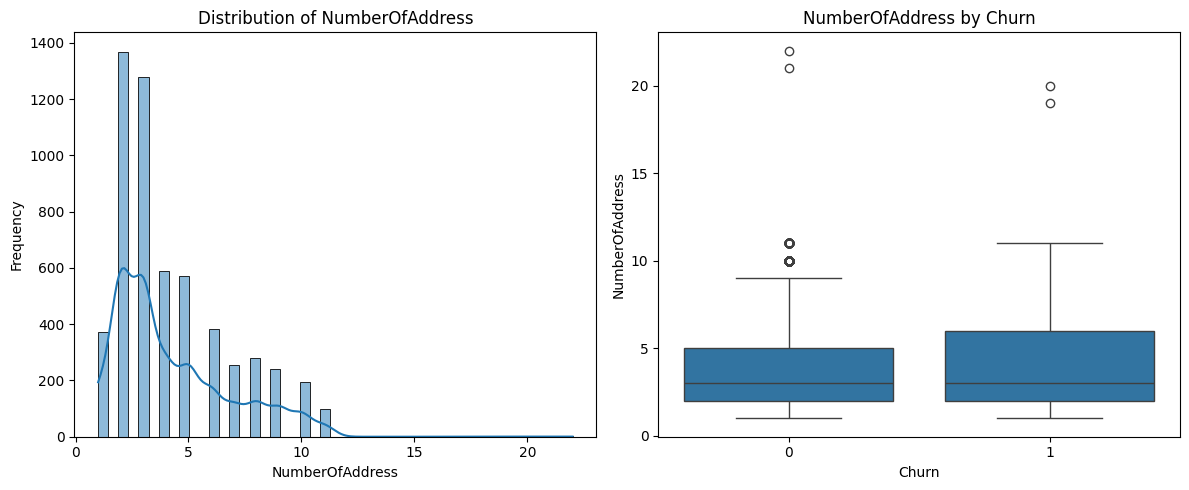

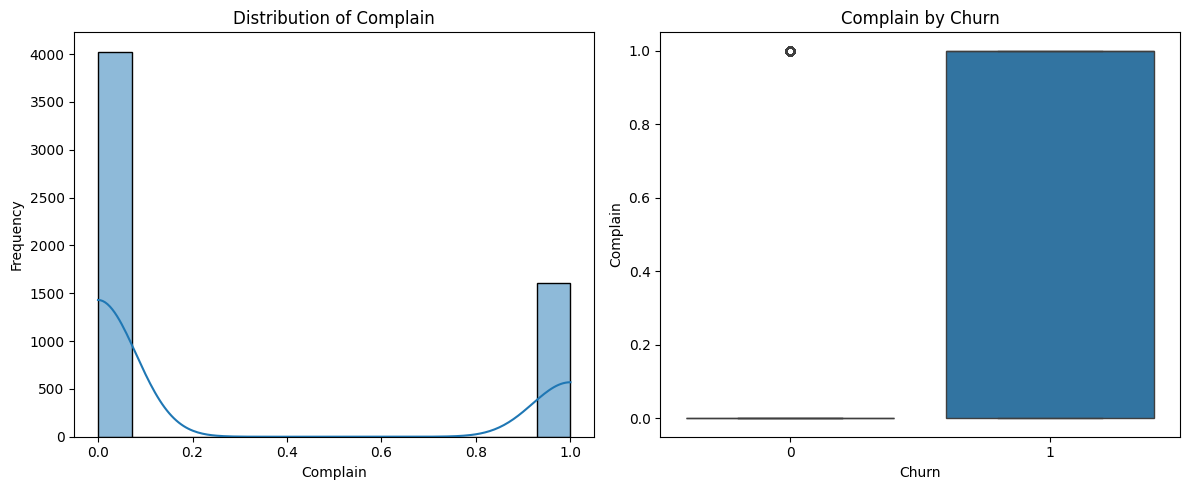

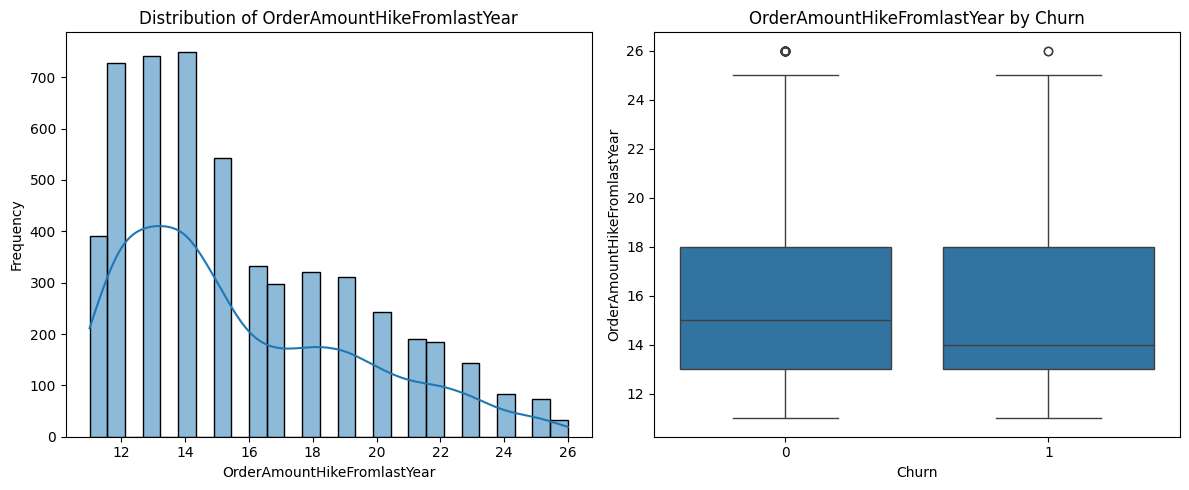

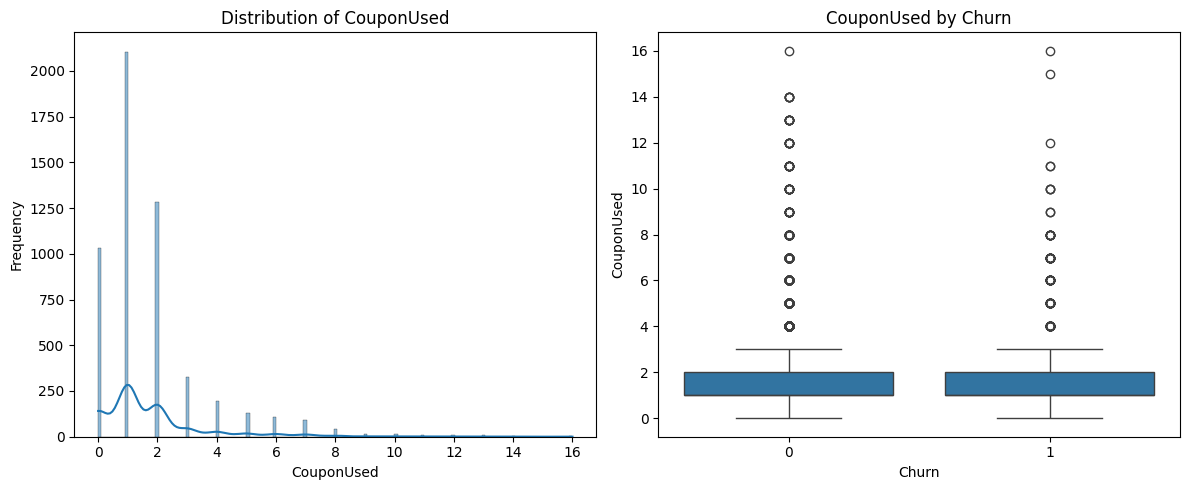

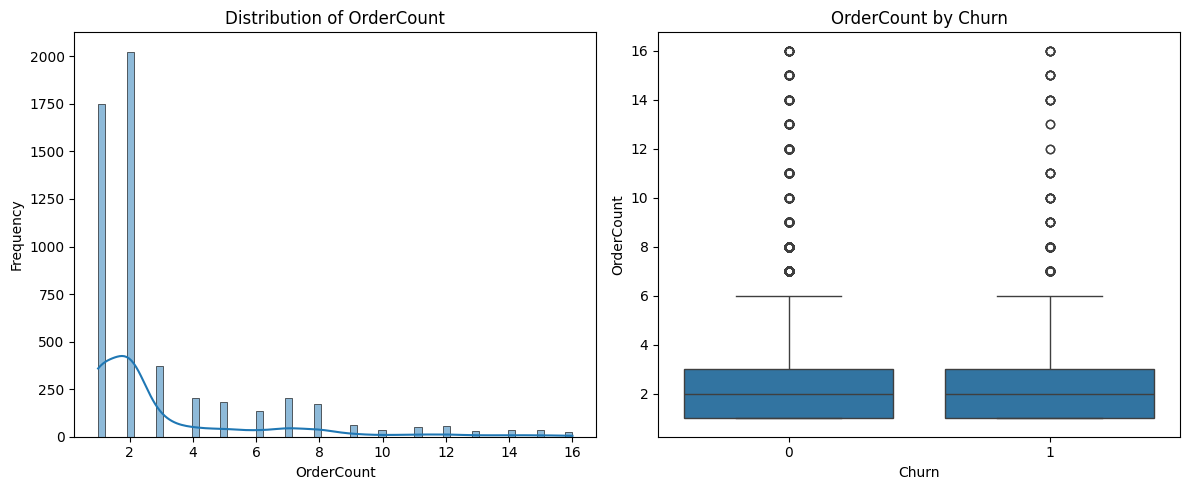

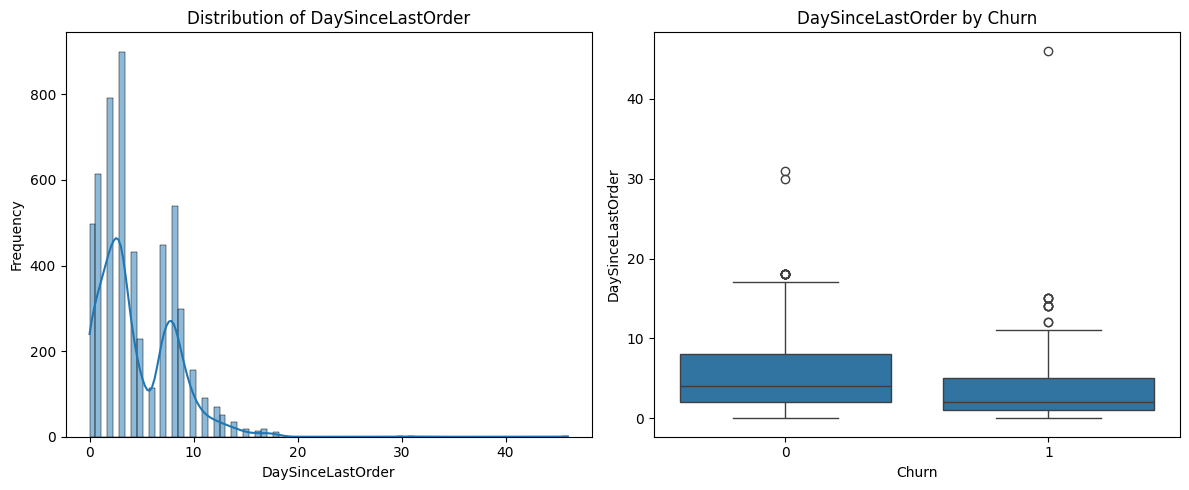

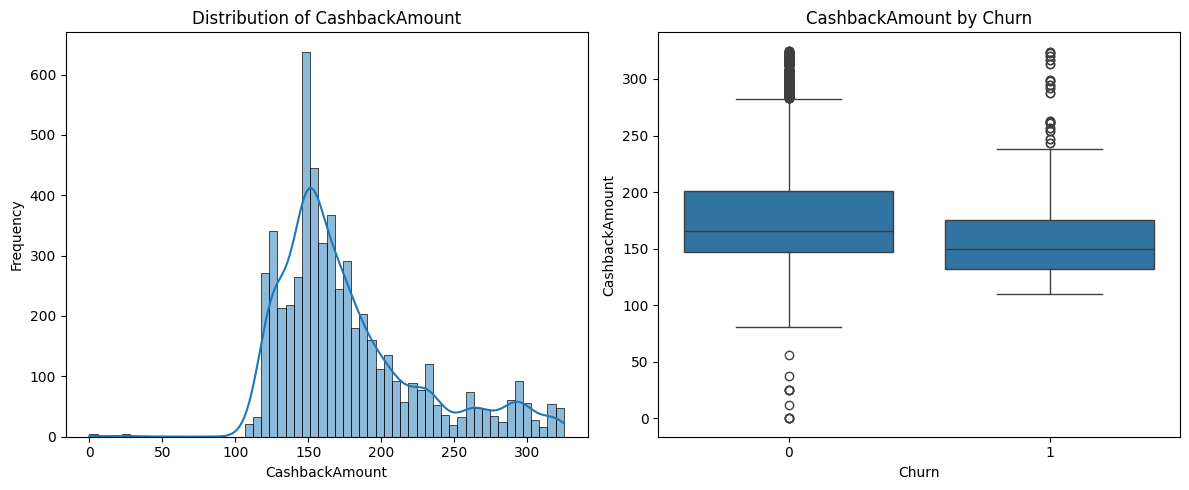

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

TARGET_COL = 'Churn'
CUSTOMER_ID_COL = 'CustomerID'

numerical_cols_eda = df.select_dtypes(include=np.number).columns.tolist()
numerical_cols_eda = [col for col in numerical_cols_eda if col not in [TARGET_COL, CUSTOMER_ID_COL]]

categorical_cols_eda = df.select_dtypes(include=['object', 'category']).columns.tolist()

for col in numerical_cols_eda:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    sns.histplot(df[col], kde=True, ax=axes[0])
    axes[0].set_title(f'Distribution of {col}')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Frequency')

    sns.boxplot(x=TARGET_COL, y=col, data=df, ax=axes[1])
    axes[1].set_title(f'{col} by {TARGET_COL}')
    axes[1].set_xlabel(TARGET_COL)
    axes[1].set_ylabel(col)

    plt.tight_layout()
    plt.show()

### 2.2 Categorical Feature Distributions

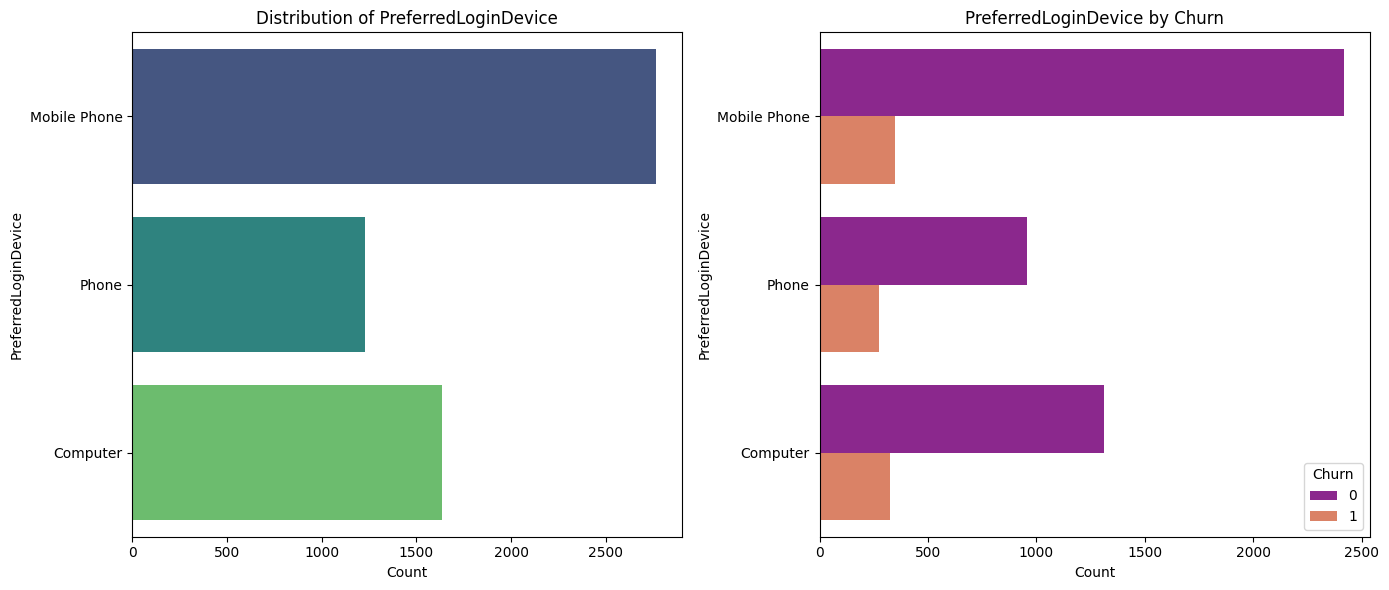

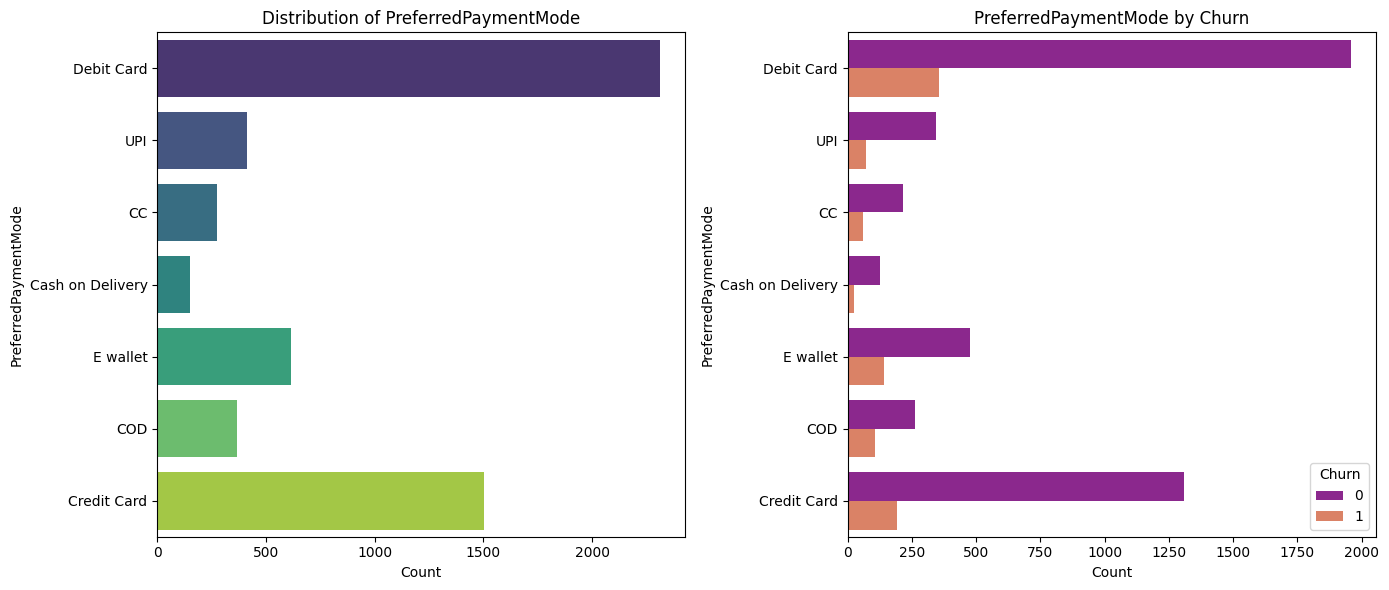

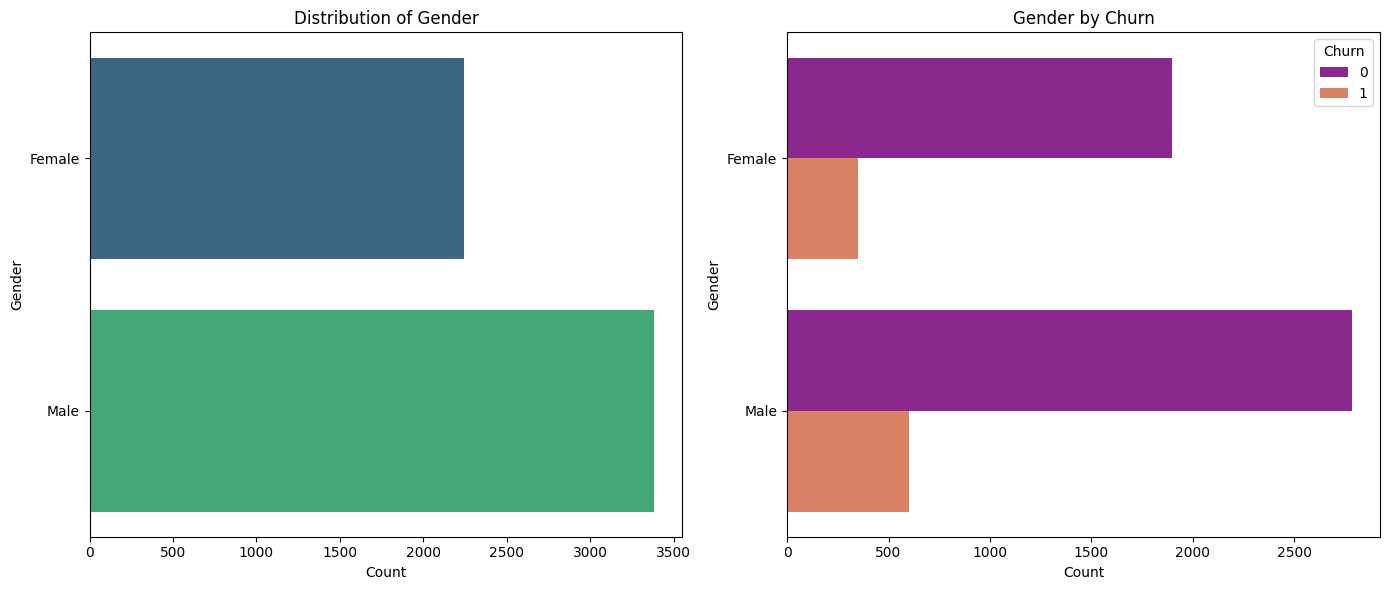

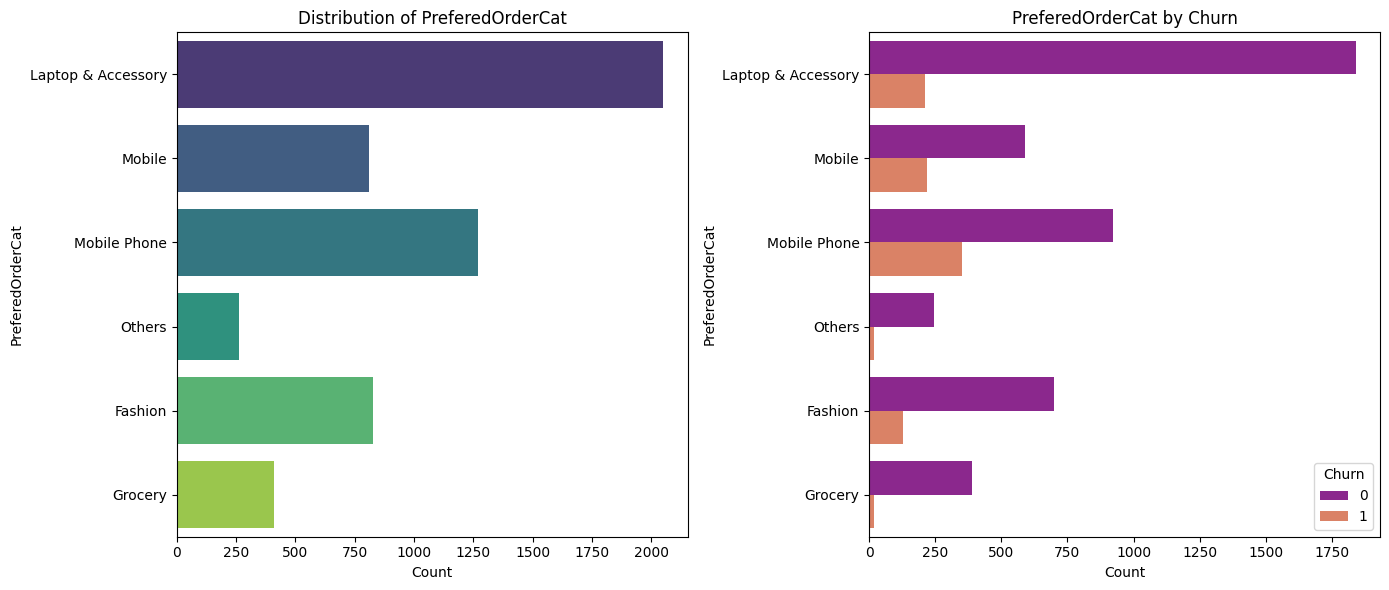

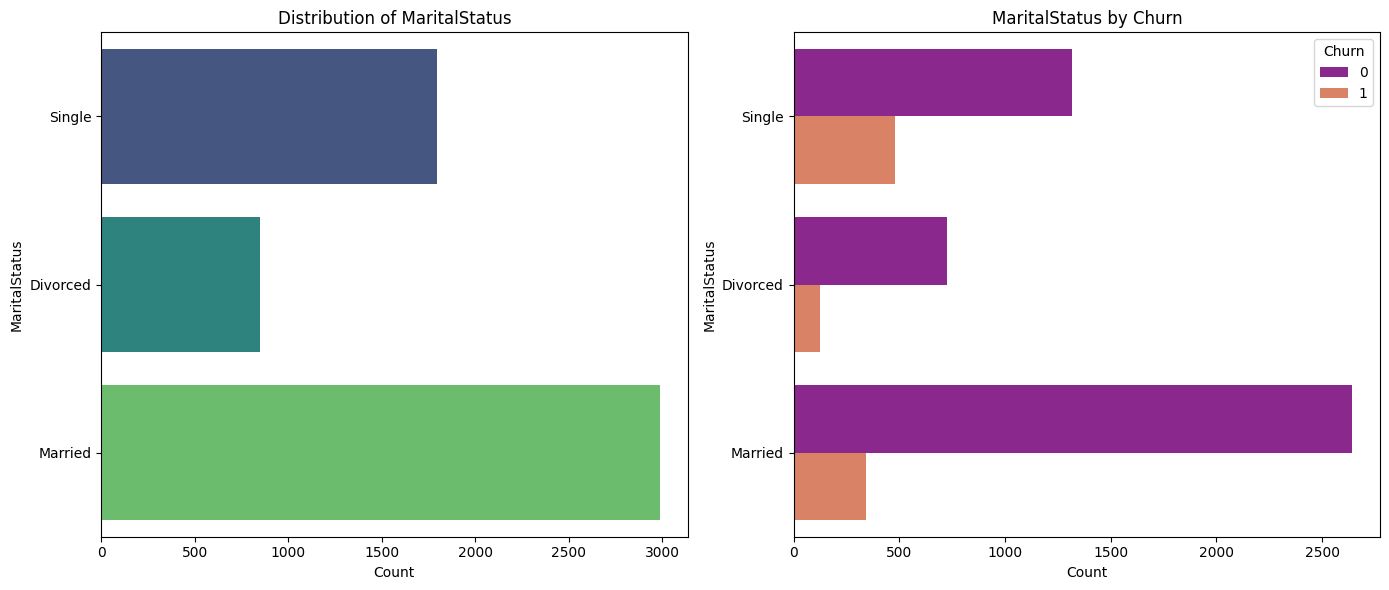

In [48]:
for col in categorical_cols_eda:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    sns.countplot(y=col, data=df, ax=axes[0], palette='viridis')
    axes[0].set_title(f'Distribution of {col}')
    axes[0].set_xlabel('Count')
    axes[0].set_ylabel(col)

    sns.countplot(y=col, hue=TARGET_COL, data=df, ax=axes[1], palette='plasma')
    axes[1].set_title(f'{col} by {TARGET_COL}')
    axes[1].set_xlabel('Count')
    axes[1].set_ylabel(col)
    axes[1].legend(title=TARGET_COL)

    plt.tight_layout()
    plt.show()

---
## 3. Advanced Feature Engineering

Creating interaction features and domain-specific metrics to improve model performance:
1. **RFM-style features** (Recency, Frequency, Monetary patterns)
2. **Tenure / Lifecycle features**
3. **Satisfaction and complaint features**
4. **Engagement composite features**
5. **Domain-encoded risk scores**
6. **Distance and delivery features**
7. **Log transforms** (reduce skewness)
8. **Polynomial features**
9. **Cashback tier** (loyalty segmentation)
10. **Composite churn risk score**

In [49]:
print("=" * 70)
print("ADVANCED FEATURE ENGINEERING FROM RAW COLUMNS")
print("=" * 70)

df_fe = df.copy()

def safe_div(a, b, fill=0.0):
    return np.where(b != 0, a / b, fill)

# BLOCK 1: RFM-STYLE FEATURES
print("\n[1] RFM-style features...")
df_fe['Recency_Score']      = safe_div(df_fe['DaySinceLastOrder'], df_fe['Tenure'] + 1)
df_fe['Order_Frequency']    = safe_div(df_fe['OrderCount'], df_fe['Tenure'] + 1)
df_fe['Cashback_per_Order'] = safe_div(df_fe['CashbackAmount'], df_fe['OrderCount'] + 1)
df_fe['Coupon_per_Order']   = safe_div(df_fe['CouponUsed'], df_fe['OrderCount'] + 1)
df_fe['AvgHike_per_Order']  = safe_div(df_fe['OrderAmountHikeFromlastYear'], df_fe['OrderCount'] + 1)
df_fe['Recency_Bin'] = pd.cut(
    df_fe['DaySinceLastOrder'], bins=[-1, 5, 15, 30, 9999], labels=[0, 1, 2, 3]
).astype(float)

# BLOCK 2: TENURE / LIFECYCLE FEATURES
print("[2] Tenure / lifecycle features...")
df_fe['Lifecycle_Stage'] = pd.cut(
    df_fe['Tenure'], bins=[-1, 1, 6, 12, 9999], labels=[0, 1, 2, 3]
).astype(float)
df_fe['Tenure_sq']           = df_fe['Tenure'] ** 2
df_fe['App_Hours_per_Month'] = safe_div(df_fe['HourSpendOnApp'], df_fe['Tenure'] + 1)
df_fe['Address_per_Month']   = safe_div(df_fe['NumberOfAddress'], df_fe['Tenure'] + 1)
df_fe['Device_per_Month']    = safe_div(df_fe['NumberOfDeviceRegistered'], df_fe['Tenure'] + 1)

# BLOCK 3: SATISFACTION & COMPLAINT FEATURES
print("[3] Satisfaction & complaint features...")
df_fe['Inv_Satisfaction']        = 6 - df_fe['SatisfactionScore']
df_fe['Satisfaction_sq']         = df_fe['SatisfactionScore'] ** 2
df_fe['Complaint_Severity']      = df_fe['Complain'] * df_fe['Inv_Satisfaction']
df_fe['Satisfaction_Decay']      = safe_div(df_fe['Inv_Satisfaction'], df_fe['Tenure'] + 1)
df_fe['Chronic_Dissatisfaction'] = ((df_fe['Complain'] == 1) & (df_fe['SatisfactionScore'] <= 2)).astype(int)
df_fe['High_Risk_Flag']          = ((df_fe['Complain'] == 1) & (df_fe['SatisfactionScore'] <= 3)).astype(int)

# BLOCK 4: ENGAGEMENT COMPOSITE FEATURES
print("[4] Engagement composite features...")
_h  = df_fe['HourSpendOnApp']  / (df_fe['HourSpendOnApp'].max()  + 1e-9)
_oc = df_fe['OrderCount']      / (df_fe['OrderCount'].max()      + 1e-9)
_cu = df_fe['CouponUsed']      / (df_fe['CouponUsed'].max()      + 1e-9)
df_fe['Engagement_Score']      = (_h + _oc + _cu) / 3.0 * 100
df_fe['Low_Engagement_Flag']   = (df_fe['Order_Frequency'] < 1).astype(int)
df_fe['Tenure_x_OrderCount']   = df_fe['Tenure'] * df_fe['OrderCount']
df_fe['App_x_Coupon']          = df_fe['HourSpendOnApp'] * df_fe['CouponUsed']
df_fe['Satisfaction_x_Orders'] = df_fe['SatisfactionScore'] * df_fe['OrderCount']

# BLOCK 5: DOMAIN-ENCODED RISK SCORES
print("[5] Domain-encoded risk scores...")
_pay_risk = {
    'Cash on Delivery': 3, 'COD': 3,
    'E wallet': 2, 'UPI': 2,
    'Debit Card': 1, 'Credit Card': 1, 'CC': 1,
}
df_fe['Payment_Risk']  = df_fe['PreferredPaymentMode'].map(_pay_risk).fillna(2).astype(int)
_cat_risk = {
    'Mobile': 3, 'Mobile Phone': 3,
    'Laptop & Accessory': 2, 'Others': 2,
    'Fashion': 1, 'Grocery': 1,
}
df_fe['Category_Risk'] = df_fe['PreferedOrderCat'].map(_cat_risk).fillna(2).astype(int)
df_fe['CityTier_Risk'] = df_fe['CityTier'].map({1: 1, 2: 2, 3: 3}).fillna(2).astype(int)

# BLOCK 6: DISTANCE & DELIVERY FEATURES
print("[6] Distance & delivery features...")
df_fe['Log_WarehouseToHome']        = np.log1p(df_fe['WarehouseToHome'].clip(lower=0))
df_fe['Far_Warehouse']              = (df_fe['WarehouseToHome'] > df_fe['WarehouseToHome'].quantile(0.75)).astype(int)
df_fe['Distance_x_Dissatisfaction'] = df_fe['WarehouseToHome'] * df_fe['Inv_Satisfaction']

# BLOCK 7: LOG TRANSFORMS
print("[7] Log-transformed skewed numerics...")
for _col in ['CashbackAmount', 'OrderAmountHikeFromlastYear',
             'DaySinceLastOrder', 'NumberOfAddress',
             'CouponUsed', 'OrderCount']:
    df_fe[f'Log_{_col}'] = np.log1p(df_fe[_col].clip(lower=0))

# BLOCK 8: POLYNOMIAL FEATURES
print("[8] Polynomial (squared) features...")
for _col in ['DaySinceLastOrder', 'CashbackAmount', 'WarehouseToHome']:
    df_fe[f'{_col}_sq'] = df_fe[_col] ** 2

# BLOCK 9: CASHBACK TIER
print("[9] Cashback loyalty tier...")
df_fe['Cashback_Tier'] = pd.cut(
    df_fe['CashbackAmount'],
    bins=[-1, 100, 175, 250, 99999],
    labels=['Low', 'Medium', 'High', 'Premium']
).astype(str)

# BLOCK 10: COMPOSITE CHURN RISK SCORE
print("[10] Composite churn risk score...")
_dsl_norm = df_fe['DaySinceLastOrder'] / (df_fe['DaySinceLastOrder'].max() + 1e-9)
_ten_norm = 1 - df_fe['Tenure'] / (df_fe['Tenure'].max() + 1e-9)
_cb_norm  = 1 - df_fe['CashbackAmount'] / (df_fe['CashbackAmount'].max() + 1e-9)
df_fe['Composite_Risk_Score'] = (
    df_fe['Complain'] * 3.0 +
    df_fe['Inv_Satisfaction'] +
    _dsl_norm +
    _ten_norm +
    _cb_norm
)

new_features = [c for c in df_fe.columns if c not in df.columns]
print(f"\n  {len(new_features)} new features created from raw columns.")
print(f"\nOriginal shape : {df.shape}")
print(f"Enhanced shape : {df_fe.shape}  (+{len(new_features)} features)")

df = df_fe.copy()

ADVANCED FEATURE ENGINEERING FROM RAW COLUMNS

[1] RFM-style features...
[2] Tenure / lifecycle features...
[3] Satisfaction & complaint features...
[4] Engagement composite features...
[5] Domain-encoded risk scores...
[6] Distance & delivery features...
[7] Log-transformed skewed numerics...
[8] Polynomial (squared) features...
[9] Cashback loyalty tier...
[10] Composite churn risk score...

  39 new features created from raw columns.

Original shape : (5630, 20)
Enhanced shape : (5630, 59)  (+39 features)


In [50]:
print(f"Final engineered dataframe: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nAll columns:")
for c in df.columns:
    print(f"  {c}  [{df[c].dtype}]")

Final engineered dataframe: 5,630 rows x 59 columns

All columns:
  CustomerID  [int64]
  Churn  [int64]
  Tenure  [float64]
  PreferredLoginDevice  [object]
  CityTier  [int64]
  WarehouseToHome  [float64]
  PreferredPaymentMode  [object]
  Gender  [object]
  HourSpendOnApp  [float64]
  NumberOfDeviceRegistered  [int64]
  PreferedOrderCat  [object]
  SatisfactionScore  [int64]
  MaritalStatus  [object]
  NumberOfAddress  [int64]
  Complain  [int64]
  OrderAmountHikeFromlastYear  [float64]
  CouponUsed  [float64]
  OrderCount  [float64]
  DaySinceLastOrder  [float64]
  CashbackAmount  [int64]
  Recency_Score  [float64]
  Order_Frequency  [float64]
  Cashback_per_Order  [float64]
  Coupon_per_Order  [float64]
  AvgHike_per_Order  [float64]
  Recency_Bin  [float64]
  Lifecycle_Stage  [float64]
  Tenure_sq  [float64]
  App_Hours_per_Month  [float64]
  Address_per_Month  [float64]
  Device_per_Month  [float64]
  Inv_Satisfaction  [int64]
  Satisfaction_sq  [int64]
  Complaint_Severity  [in

---
## 4. Preprocessing

### 4.1 Identify Column Types

In [51]:
TARGET_COL = 'Churn'
CUSTOMER_ID_COL = 'CustomerID'

numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
numerical_cols = [col for col in numerical_cols if col not in [TARGET_COL, CUSTOMER_ID_COL]]

categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

for col in categorical_cols:
    if df[col].dtype.name == 'category':
        df[col] = df[col].astype(str)

print(f"Numerical columns (excluding '{TARGET_COL}' and '{CUSTOMER_ID_COL}'): {numerical_cols}")
print(f"Categorical columns (object + category): {categorical_cols}")

Numerical columns (excluding 'Churn' and 'CustomerID'): ['Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount', 'Recency_Score', 'Order_Frequency', 'Cashback_per_Order', 'Coupon_per_Order', 'AvgHike_per_Order', 'Recency_Bin', 'Lifecycle_Stage', 'Tenure_sq', 'App_Hours_per_Month', 'Address_per_Month', 'Device_per_Month', 'Inv_Satisfaction', 'Satisfaction_sq', 'Complaint_Severity', 'Satisfaction_Decay', 'Chronic_Dissatisfaction', 'High_Risk_Flag', 'Engagement_Score', 'Low_Engagement_Flag', 'Tenure_x_OrderCount', 'App_x_Coupon', 'Satisfaction_x_Orders', 'Payment_Risk', 'Category_Risk', 'CityTier_Risk', 'Log_WarehouseToHome', 'Far_Warehouse', 'Distance_x_Dissatisfaction', 'Log_CashbackAmount', 'Log_OrderAmountHikeFromlastYear', 'Log_DaySinceLastOrder', 'Log_NumberOfAddress', 'Log_CouponUsed', 'Log_OrderCount', 

### 4.2 Handle Missing Values

Fill missing values with column mean (numerical) to preserve the column's overall distribution and sample size. Scale numerical columns using StandardScaler.

In [52]:
from sklearn.preprocessing import StandardScaler

# Fill missing values with column mean to preserve the column's overall distribution and sample size
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].mean())

# Then scale
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

print("Missing values filled with column mean and numerical features scaled.")
print(f"Number of scaled columns: {len(numerical_cols)}")

Missing values filled with column mean and numerical features scaled.
Number of scaled columns: 51


### 4.3 Train/Test Split

In [53]:
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Fill missing values using training-set means only (prevents data leakage)
X_train[numerical_cols] = X_train[numerical_cols].fillna(X_train[numerical_cols].mean())
X_test[numerical_cols] = X_test[numerical_cols].fillna(X_train[numerical_cols].mean())

# Scale using training set only
scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"\n--- Target distribution in training set ---")
print(y_train.value_counts(normalize=True))
print(f"\n--- Target distribution in test set ---")
print(y_test.value_counts(normalize=True))

X_train shape: (4504, 58)
X_test shape:  (1126, 58)

--- Target distribution in training set ---
Churn
0    0.831705
1    0.168295
Name: proportion, dtype: float64

--- Target distribution in test set ---
Churn
0    0.831261
1    0.168739
Name: proportion, dtype: float64


### 4.4 One-Hot Encode Categorical Features

One-hot encode train and test separately, then align columns to ensure the test set has the same columns as the training set.

In [54]:
categorical_cols = ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender',
                    'PreferedOrderCat', 'MaritalStatus', 'Cashback_Tier']

# Ensure all categorical columns are strings
X_train[categorical_cols] = X_train[categorical_cols].astype(str)
X_test[categorical_cols] = X_test[categorical_cols].astype(str)

# One-hot encode training data
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=False, dtype=int)

# One-hot encode test data
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, drop_first=False, dtype=int)

# Align columns: ensures test has same columns as train
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

print(f"X_train_encoded shape: {X_train_encoded.shape}")
print(f"X_test_encoded shape:  {X_test_encoded.shape}")
print(f"\nEncoded training data sample:")
print(X_train_encoded.head())

X_train_encoded shape: (4504, 77)
X_test_encoded shape:  (1126, 77)

Encoded training data sample:
      CustomerID    Tenure  CityTier  WarehouseToHome  HourSpendOnApp  \
1787       51788 -0.142204  1.453559         0.034155       -1.321720   
2147       52148 -0.501728  1.453559        -0.328329       -2.738934   
1717       51718 -0.262045 -0.724000        -0.086673        0.095494   
2292       52293  0.576844  1.453559        -0.569984        0.095494   
5578       55579  0.217320 -0.724000        -0.328329        1.512709   

      NumberOfDeviceRegistered  SatisfactionScore  NumberOfAddress  Complain  \
1787                 -0.675976          -1.493573        -0.856755 -0.623912   
2147                 -0.675976           0.673881        -1.246653 -0.623912   
1717                  0.294877           0.673881         2.262432 -0.623912   
2292                 -0.675976           0.673881         2.262432  1.602791   
5578                  1.265730          -0.048604        -0.07

### 4.5 Handle Class Imbalance (SMOTE)

Use SMOTE (Synthetic Minority Over-sampling Technique) for upsampling. SMOTE creates new, synthetic data points rather than duplicating existing ones. Its main advantages over naive methods like random oversampling include reduced overfitting, improved model generalisation, and better preservation of minority class information.

In [55]:
from imblearn.over_sampling import SMOTE

print("--- Target distribution before SMOTE ---")
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_encoded, y_train)

print("\n--- Target distribution after SMOTE ---")
print(y_train_smote.value_counts())
print(f"\nX_train_smote shape: {X_train_smote.shape}")
print(f"X_test_encoded shape: {X_test_encoded.shape}")
print("\nDataset for modelling: X_train_smote, X_test_encoded, y_train_smote, y_test")

--- Target distribution before SMOTE ---
Churn
0    3746
1     758
Name: count, dtype: int64

--- Target distribution after SMOTE ---
Churn
0    3746
1    3746
Name: count, dtype: int64

X_train_smote shape: (7492, 77)
X_test_encoded shape: (1126, 77)

Dataset for modelling: X_train_smote, X_test_encoded, y_train_smote, y_test


---
## 5. Models

### 5.1 Logistic Regression

In [56]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)
log_reg.fit(X_train_smote, y_train_smote)

y_pred_log_reg = log_reg.predict(X_test_encoded)
y_pred_proba_log_reg = log_reg.predict_proba(X_test_encoded)[:, 1]

roc_auc_log_reg = roc_auc_score(y_test, y_pred_proba_log_reg)
avg_precision_log_reg = average_precision_score(y_test, y_pred_proba_log_reg)
conf_matrix_log_reg = confusion_matrix(y_test, y_pred_log_reg)

print(f"Logistic Regression ROC AUC: {roc_auc_log_reg:.4f}")
print(f"Logistic Regression Average Precision: {avg_precision_log_reg:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_log_reg))
print(f"Confusion Matrix:")
print(conf_matrix_log_reg)

Logistic Regression ROC AUC: 0.9002
Logistic Regression Average Precision: 0.7585

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       936
           1       0.77      0.68      0.72       190

    accuracy                           0.91      1126
   macro avg       0.85      0.82      0.84      1126
weighted avg       0.91      0.91      0.91      1126

Confusion Matrix:
[[898  38]
 [ 61 129]]


### 5.2 Random Forest (Baseline + Tuned)

In [57]:
from sklearn.ensemble import RandomForestClassifier

# --- Baseline Random Forest ---
rf_baseline = RandomForestClassifier(random_state=42)
rf_baseline.fit(X_train_smote, y_train_smote)

y_pred_rf_base = rf_baseline.predict(X_test_encoded)
y_pred_proba_rf_base = rf_baseline.predict_proba(X_test_encoded)[:, 1]

print("--- Baseline Random Forest ---")
print(f"ROC AUC: {roc_auc_score(y_test, y_pred_proba_rf_base):.4f}")
print(f"Average Precision: {average_precision_score(y_test, y_pred_proba_rf_base):.4f}")
print(classification_report(y_test, y_pred_rf_base))
print(confusion_matrix(y_test, y_pred_rf_base))

--- Baseline Random Forest ---
ROC AUC: 0.9967
Average Precision: 0.9819
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       936
           1       0.95      0.93      0.94       190

    accuracy                           0.98      1126
   macro avg       0.97      0.96      0.96      1126
weighted avg       0.98      0.98      0.98      1126

[[926  10]
 [ 14 176]]


In [ ]:
# --- Tuned Random Forest ---
param_dist_rf = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

random_search_rf = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist_rf,
    n_iter=50, scoring='roc_auc', cv=5,
    verbose=1, random_state=42, n_jobs=-1
)
random_search_rf.fit(X_train_smote, y_train_smote)

best_rf = random_search_rf.best_estimator_
print("Best Parameters:", random_search_rf.best_params_)

y_pred_rf = best_rf.predict(X_test_encoded)
y_pred_proba_rf = best_rf.predict_proba(X_test_encoded)[:, 1]

roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
avg_precision_rf = average_precision_score(y_test, y_pred_proba_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

print(f"\nTuned Random Forest ROC AUC: {roc_auc_rf:.4f}")
print(f"Tuned Random Forest Average Precision: {avg_precision_rf:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_rf))
print(f"Confusion Matrix:")
print(conf_matrix_rf)


'\n# --- Tuned Random Forest ---\nparam_dist_rf = {\n    \'n_estimators\': [100, 200, 300, 500],\n    \'max_depth\': [None, 10, 20, 30, 50],\n    \'min_samples_split\': [2, 5, 10],\n    \'min_samples_leaf\': [1, 2, 4],\n    \'max_features\': [\'sqrt\', \'log2\', None],\n    \'bootstrap\': [True, False]\n}\n\nrandom_search_rf = RandomizedSearchCV(\n    estimator=RandomForestClassifier(random_state=42),\n    param_distributions=param_dist_rf,\n    n_iter=50, scoring=\'roc_auc\', cv=5,\n    verbose=1, random_state=42, n_jobs=-1\n)\nrandom_search_rf.fit(X_train_smote, y_train_smote)\n\nbest_rf = random_search_rf.best_estimator_\nprint("Best Parameters:", random_search_rf.best_params_)\n\ny_pred_rf = best_rf.predict(X_test_encoded)\ny_pred_proba_rf = best_rf.predict_proba(X_test_encoded)[:, 1]\n\nroc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)\navg_precision_rf = average_precision_score(y_test, y_pred_proba_rf)\nconf_matrix_rf = confusion_matrix(y_test, y_pred_rf)\n\nprint(f"\nTuned Ran

### 5.3 Gradient Boosting (HistGradientBoosting — Baseline + Tuned)

In [59]:
from sklearn.ensemble import HistGradientBoostingClassifier

# --- Baseline ---
gb_baseline = HistGradientBoostingClassifier(random_state=42)
gb_baseline.fit(X_train_smote, y_train_smote)

y_pred_gb_base = gb_baseline.predict(X_test_encoded)
y_pred_proba_gb_base = gb_baseline.predict_proba(X_test_encoded)[:, 1]

print("--- Baseline HistGradientBoosting ---")
print(f"ROC AUC: {roc_auc_score(y_test, y_pred_proba_gb_base):.4f}")
print(f"Average Precision: {average_precision_score(y_test, y_pred_proba_gb_base):.4f}")
print(classification_report(y_test, y_pred_gb_base))
print(confusion_matrix(y_test, y_pred_gb_base))

--- Baseline HistGradientBoosting ---
ROC AUC: 0.9959
Average Precision: 0.9782
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       936
           1       0.95      0.89      0.92       190

    accuracy                           0.97      1126
   macro avg       0.96      0.94      0.95      1126
weighted avg       0.97      0.97      0.97      1126

[[927   9]
 [ 20 170]]


In [60]:
# --- Tuned HistGradientBoosting ---
param_dist_gb = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_iter': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_leaf': [20, 30, 50],
    'l2_regularization': [0.0, 0.1, 1.0],
    'max_bins': [255, 200]
}

random_search_gb = RandomizedSearchCV(
    estimator=HistGradientBoostingClassifier(random_state=42),
    param_distributions=param_dist_gb,
    n_iter=40, scoring='roc_auc', cv=5,
    verbose=1, random_state=42, n_jobs=-1
)
random_search_gb.fit(X_train_smote, y_train_smote)

best_gb = random_search_gb.best_estimator_
print("Best Parameters:", random_search_gb.best_params_)

y_pred_gb = best_gb.predict(X_test_encoded)
y_pred_proba_gb = best_gb.predict_proba(X_test_encoded)[:, 1]

roc_auc_gb = roc_auc_score(y_test, y_pred_proba_gb)
avg_precision_gb = average_precision_score(y_test, y_pred_proba_gb)
conf_matrix_gb = confusion_matrix(y_test, y_pred_gb)

print(f"\nTuned HistGradientBoosting ROC AUC: {roc_auc_gb:.4f}")
print(f"Tuned HistGradientBoosting Average Precision: {avg_precision_gb:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_gb))
print(f"Confusion Matrix:")
print(conf_matrix_gb)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best Parameters: {'min_samples_leaf': 20, 'max_iter': 300, 'max_depth': 10, 'max_bins': 255, 'learning_rate': 0.05, 'l2_regularization': 0.0}

Tuned HistGradientBoosting ROC AUC: 0.9988
Tuned HistGradientBoosting Average Precision: 0.9937

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       936
           1       0.98      0.92      0.95       190

    accuracy                           0.98      1126
   macro avg       0.98      0.96      0.97      1126
weighted avg       0.98      0.98      0.98      1126

Confusion Matrix:
[[933   3]
 [ 16 174]]


### 5.4 XGBoost (Baseline + Tuned)

In [61]:
from xgboost import XGBClassifier

# --- Baseline XGBoost ---
xgb_baseline = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_baseline.fit(X_train_smote, y_train_smote)

y_pred_xgb_base = xgb_baseline.predict(X_test_encoded)
y_pred_proba_xgb_base = xgb_baseline.predict_proba(X_test_encoded)[:, 1]

print("--- Baseline XGBoost ---")
print(f"ROC AUC: {roc_auc_score(y_test, y_pred_proba_xgb_base):.4f}")
print(f"Average Precision: {average_precision_score(y_test, y_pred_proba_xgb_base):.4f}")
print(classification_report(y_test, y_pred_xgb_base))
print(confusion_matrix(y_test, y_pred_xgb_base))

--- Baseline XGBoost ---
ROC AUC: 0.9987
Average Precision: 0.9934
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       936
           1       0.97      0.95      0.96       190

    accuracy                           0.99      1126
   macro avg       0.98      0.97      0.97      1126
weighted avg       0.99      0.99      0.99      1126

[[930   6]
 [ 10 180]]


In [ ]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import numpy as np

xgb_clf = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

param_dist = {
    'n_estimators': [100, 200, 500, 800],
    'max_depth': [3, 5, 7, 10, 15],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3, 0.5],
    'min_child_weight': [1, 3, 5, 7]
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=xgb_clf,
    param_distributions=param_dist,
    n_iter=50,                  # number of random combinations to try
    scoring='accuracy',          # can change to 'f1' or 'roc_auc'
    cv=skf,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_smote, y_train_smote)

print("Best Parameters:", random_search.best_params_)
print("Best CV Accuracy:", random_search.best_score_)

best_xgb = random_search.best_estimator_
y_pred = best_xgb.predict(X_test_encoded)
y_proba = best_xgb.predict_proba(X_test_encoded)[:,1]
conf_matrix_xgb = confusion_matrix(y_test, y_pred)

print("\n=== Test Set Evaluation ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters: {'subsample': 1.0, 'n_estimators': 800, 'min_child_weight': 3, 'max_depth': 15, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.8}
Best CV Accuracy: 0.9774420151930393

=== Test Set Evaluation ===
Accuracy: 0.9928952042628775
F1 Score: 0.9786096256684492
ROC AUC: 0.9995501574448943
Confusion Matrix:
 [[935   1]
 [  7 183]]
Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00       936
           1       0.99      0.96      0.98       190

    accuracy                           0.99      1126
   macro avg       0.99      0.98      0.99      1126
weighted avg       0.99      0.99      0.99      1126



### 5.6 LSTM

LSTM is applied by treating the feature vector as a single time-step sequence. Although this is tabular data (not inherently sequential), the LSTM is included for comparison.

In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)
from sklearn.utils.class_weight import compute_class_weight

# use weight instead of SMOTE
X_train_lstm = np.array(X_train_encoded).reshape(X_train_encoded.shape[0], X_train_encoded.shape[1], 1)
X_test_lstm = np.array(X_test_encoded).reshape(X_test_encoded.shape[0], X_test_encoded.shape[1], 1)

model = Sequential([
    LSTM(64, input_shape=(X_train_lstm.shape[1], 1)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = {0: weights[0], 1: weights[1]}
print(class_weights)

history = model.fit(
    X_train_lstm, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    class_weight=class_weights,
    verbose=1
)

y_proba = model.predict(X_test_lstm).ravel()
'''
for t in [0.4, 0.45, 0.5, 0.55, 0.6]:
    y_pred = (y_proba >= t).astype(int)
    print(f"Threshold: {t}")
    print("Precision:", precision_score(y_test, y_pred, zero_division=0))
    print("Recall:", recall_score(y_test, y_pred, zero_division=0))
    print("F1:", f1_score(y_test, y_pred, zero_division=0))
    print("-" * 30)
    '''
# best threshold is 0.4, highest recall

best_threshold = 0.4
y_pred_best = (y_proba >= best_threshold).astype(int)
conf_matrix_lstm = confusion_matrix(y_test, y_pred_best)

print(f"Best Threshold: {best_threshold}")
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_best, zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred_best, zero_division=0))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_best))
print("Classification Report:\n", classification_report(y_test, y_pred_best, zero_division=0))

{0: np.float64(0.601174586225307), 1: np.float64(2.970976253298153)}
Epoch 1/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.5968 - loss: 0.6867 - val_accuracy: 0.8180 - val_loss: 0.6826
Epoch 2/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.5868 - loss: 0.6862 - val_accuracy: 0.8180 - val_loss: 0.6697
Epoch 3/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.4722 - loss: 0.6980 - val_accuracy: 0.7802 - val_loss: 0.6291
Epoch 4/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.6503 - loss: 0.6614 - val_accuracy: 0.7636 - val_loss: 0.6189
Epoch 5/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.7573 - loss: 0.6360 - val_accuracy: 0.7669 - val_loss: 0.6018
Epoch 6/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.7288 - loss: 0.6120 - val_accuracy: 0.6371 - val_loss: 0.6752
Epoch 7/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.6754 - loss: 0.6219 - val_accuracy: 0.7026 - val_loss: 0.5807
Epoch 8/30
113/113 ━━━━━━━━━

The LSTM model achieved moderate predictive performance. This is expected because the dataset is tabular with no temporal sequence per customer. LSTMs are designed for sequential data and are not recommended for this data structure.

### 5.7 LightGBM (Baseline + Tuned)

In [64]:
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report

lgbm = lgb.LGBMClassifier(
    objective='binary',
    random_state=42,
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=5,
    min_child_samples=40,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=2
)

param_dist = {
    'n_estimators': [100, 200, 500, 800],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [15, 31, 63, 127],
    'max_depth': [-1, 5, 10, 20],
    'min_child_samples': [10, 20, 30, 50],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_dist,
    n_iter=30,
    scoring='f1',
    cv=skf,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_smote, y_train_smote)

print("Best Parameters:", random_search.best_params_)
print("Best CV Score:", random_search.best_score_)

best_lgbm = random_search.best_estimator_
y_pred = best_lgbm.predict(X_test_encoded)
y_proba = best_lgbm.predict_proba(X_test_encoded)[:, 1]

print("\n=== Test Set Evaluation ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 3746, number of negative: 3746
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004830 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13293
[LightGBM] [Info] Number of data points in the train set: 7492, number of used features: 76
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with po

#### LightGBM Feature Importance

In [65]:
import pandas as pd

y_train_pred = best_lgbm.predict(X_train_encoded)
y_train_proba = best_lgbm.predict_proba(X_train_encoded)[:, 1]

print("Train F1:", f1_score(y_train, y_train_pred))
print("Train ROC AUC:", roc_auc_score(y_train, y_train_proba))

importance_df = pd.DataFrame({
    'Feature': X_train_encoded.columns,
    'Importance': best_lgbm.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance_df.head(10))

Train F1: 1.0
Train ROC AUC: 1.0
                        Feature  Importance
41   Distance_x_Dissatisfaction        1710
51         Composite_Risk_Score        1521
23            Address_per_Month        1466
16           Cashback_per_Order        1287
0                    CustomerID        1079
18            AvgHike_per_Order        1074
14                Recency_Score        1067
9   OrderAmountHikeFromlastYear        1057
13               CashbackAmount         969
24             Device_per_Month         887


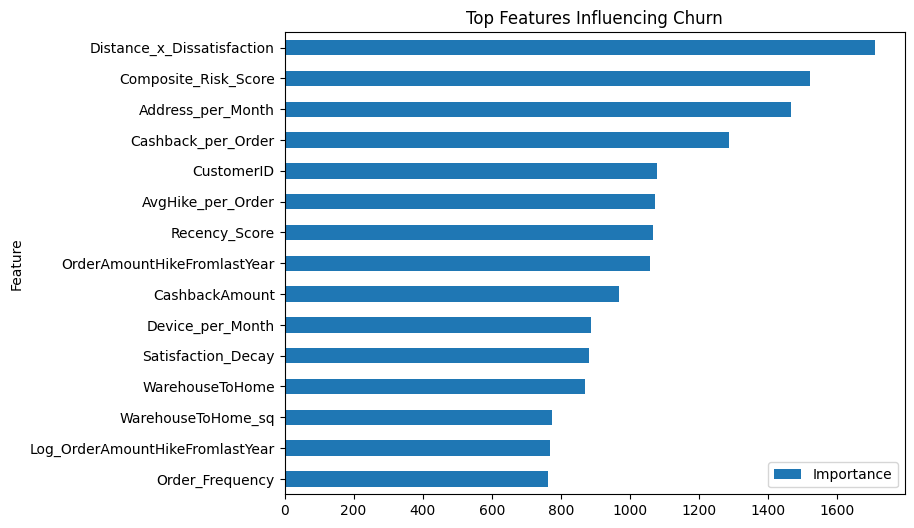

In [66]:
import matplotlib.pyplot as plt
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X_train_smote.columns,
    'Importance': best_lgbm.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance.head(15).plot(
    kind='barh',
    x='Feature',
    y='Importance',
    figsize=(8,6)
)
plt.gca().invert_yaxis()
plt.title("Top Features Influencing Churn")
plt.show()

### LightGBM with reduced feature

In [ ]:
suspicious_features = [
    'Composite_Risk_Score',
    'High_Risk_Flag',
    'Distance_x_Dissatisfaction',
    'Chronic_Dissatisfaction',
    'Payment_Risk',
    'Category_Risk',
    'CityTier_Risk'
]

existing_suspicious_features = [col for col in suspicious_features if col in X_train_encoded.columns]
print("Dropping:", existing_suspicious_features)

X_train_reduced = X_train_encoded.drop(columns=existing_suspicious_features)
X_test_reduced = X_test_encoded.drop(columns=existing_suspicious_features)

lgbm = lgb.LGBMClassifier(objective='binary', random_state=42)

param_dist = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.03, 0.05],
    'num_leaves': [15, 31],
    'max_depth': [3, 5, 7],
    'min_child_samples': [30, 50, 80],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8],
    'reg_alpha': [0.1, 0.5, 1.0],
    'reg_lambda': [1, 2, 5]
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_dist,
    n_iter=30,
    scoring='f1',
    cv=skf,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_encoded, y_train)

best_lgbm = random_search.best_estimator_
y_pred = best_lgbm.predict(X_test_encoded)
y_proba = best_lgbm.predict_proba(X_test_encoded)[:, 1]
conf_matrix_lgb = confusion_matrix(y_test, y_pred)

print("Best Parameters:", random_search.best_params_)
print("Best CV Score:", random_search.best_score_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Dropping: ['Composite_Risk_Score', 'High_Risk_Flag', 'Distance_x_Dissatisfaction', 'Chronic_Dissatisfaction', 'Payment_Risk', 'Category_Risk', 'CityTier_Risk']
Fitting 5 folds for each of 30 candidates, totalling 150 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 758, number of negative: 3746
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001980 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3297
[LightGBM] [Info] Number of data points in the train set: 4504, number of used features: 76
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.168295 -> initscore=-1.597760
[LightGBM] [Info] Start training from score -1.597760
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

### 5.8 SVM (Support Vector Machine — Baseline + Tuned)

SVM finds the optimal hyperplane that maximises the margin between classes. The RBF kernel maps features into higher-dimensional space.

In [68]:
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)

svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,
    random_state=42
)

svm_model.fit(X_train_smote, y_train_smote)

y_pred_svm = svm_model.predict(X_test_encoded)
y_prob_svm = svm_model.predict_proba(X_test_encoded)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1-score:", f1_score(y_test, y_pred_svm))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_svm))

print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))

Accuracy: 0.5026642984014209
Precision: 0.17314487632508835
Recall: 0.5157894736842106
F1-score: 0.25925925925925924
ROC-AUC: 0.5037280701754385

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.50      0.63       936
           1       0.17      0.52      0.26       190

    accuracy                           0.50      1126
   macro avg       0.50      0.51      0.44      1126
weighted avg       0.72      0.50      0.56      1126


Confusion Matrix:
 [[468 468]
 [ 92  98]]


In [ ]:
# --- Tuned SVM ---
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVC

svm_param_dist = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.1, 0.01],
    'kernel': ['rbf']
}

svm_random = RandomizedSearchCV(
    SVC(probability=True, random_state=42),
    param_distributions=svm_param_dist,
    n_iter=4,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    random_state=42
)

svm_random.fit(X_train_smote, y_train_smote)

print("Best SVM Parameters:", svm_random.best_params_)
print("Best CV ROC-AUC:", svm_random.best_score_)

best_svm = svm_random.best_estimator_

y_pred_svm = best_svm.predict(X_test_encoded)
y_prob_svm = best_svm.predict_proba(X_test_encoded)[:,1]

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1-score:", f1_score(y_test, y_pred_svm))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_svm))

print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))

Best SVM Parameters: {'kernel': 'rbf', 'gamma': 0.1, 'C': 10}
Best CV ROC-AUC: 0.9760421533767151
Accuracy: 0.8294849023090586
Precision: 0.0
Recall: 0.0
F1-score: 0.0
ROC-AUC: 0.6839265632028789

Classification Report:
               precision    recall  f1-score   support

           0       0.83      1.00      0.91       936
           1       0.00      0.00      0.00       190

    accuracy                           0.83      1126
   macro avg       0.42      0.50      0.45      1126
weighted avg       0.69      0.83      0.75      1126


Confusion Matrix:
 [[934   2]
 [190   0]]


After tuning, the SVM model still failed to identify churn cases effectively. SVMs struggle with this dataset due to high dimensionality after one-hot encoding, class imbalance, and the tabular nature of the data.

### 5.9 CatBoost

In [ ]:
!pip install catboost

from catboost import CatBoostClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)

cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    eval_metric='AUC',
    loss_function='Logloss',
    verbose=100,
    random_state=42
)

cat_model.fit(X_train_smote, y_train_smote)

y_pred_cat = cat_model.predict(X_test_encoded)
y_prob_cat = cat_model.predict_proba(X_test_encoded)[:, 1]
conf_matrix_cat = confusion_matrix(y_test, y_pred_cat)

print("Accuracy:", accuracy_score(y_test, y_pred_cat))
print("Precision:", precision_score(y_test, y_pred_cat))
print("Recall:", recall_score(y_test, y_pred_cat))
print("F1-score:", f1_score(y_test, y_pred_cat))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_cat))

print("\nClassification Report:\n", classification_report(y_test, y_pred_cat))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_cat))

You should consider upgrading via the 'c:\users\adithya\desktop\public\.venv\scripts\python.exe -m pip install --upgrade pip' command.


0:	total: 167ms	remaining: 1m 23s
100:	total: 4.76s	remaining: 18.8s
200:	total: 7.97s	remaining: 11.9s
300:	total: 10s	remaining: 6.64s
400:	total: 12.2s	remaining: 3s
499:	total: 14.4s	remaining: 0us
Accuracy: 0.9689165186500888
Precision: 0.9378531073446328
Recall: 0.8736842105263158
F1-score: 0.9046321525885559
ROC-AUC: 0.9959176788124157

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98       936
           1       0.94      0.87      0.90       190

    accuracy                           0.97      1126
   macro avg       0.96      0.93      0.94      1126
weighted avg       0.97      0.97      0.97      1126


Confusion Matrix:
 [[925  11]
 [ 24 166]]


CatBoost achieved very strong performance with native handling of categorical features and ordered boosting. It demonstrates excellent capability in identifying churners with high recall and precision.

In [71]:
# CatBoost Feature Importance
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X_train_smote.columns,
    'Importance': cat_model.get_feature_importance()
}).sort_values(by='Importance', ascending=False)

print(feature_importance.head(15))

                                Feature  Importance
32                  Low_Engagement_Flag    7.456431
8                              Complain    6.623085
23                    Address_per_Month    5.037230
71                MaritalStatus_Married    3.716618
27                   Complaint_Severity    3.593133
66  PreferedOrderCat_Laptop & Accessory    3.102721
37                        Category_Risk    2.824169
62                        Gender_Female    2.716461
72                 MaritalStatus_Single    2.404614
40                        Far_Warehouse    2.375607
53    PreferredLoginDevice_Mobile Phone    2.319273
24                     Device_per_Month    2.266869
63                          Gender_Male    2.110731
7                       NumberOfAddress    2.088395
54           PreferredLoginDevice_Phone    2.021496


---
## 6. Model Performance Summary

In [ ]:
# Build comprehensive summary table from all trained models

all_models = {
    "Logistic Regression":          (conf_matrix_log_reg, roc_auc_log_reg,    avg_precision_log_reg),
    "Random Forest (Tuned)":        (conf_matrix_rf,      roc_auc_rf,         avg_precision_rf),
    "HistGradientBoosting (Tuned)": (conf_matrix_gb,      roc_auc_gb,         avg_precision_gb),
    "XGBoost (Tuned)":              (conf_matrix_xgb,     roc_auc_score(y_test, y_proba),        average_precision_score(y_test, y_pred)),
    "LightGBM (Tuned)":             (conf_matrix_lgb,    roc_auc_score(y_test, y_proba),        average_precision_score(y_test, y_pred)),
    "LSTM":                         (conf_matrix_lstm,    roc_auc_score(y_test, y_proba),       average_precision_score(y_test, y_pred_best)),
    "SVM (Tuned)":                  (conf_matrix_svm,     roc_auc_score(y_test, y_prob_svm),        average_precision_score(y_test, y_pred_svm)),
    "CatBoost":                     (conf_matrix_cat,     roc_auc_score(y_test, y_prob_cat),        average_precision_score(y_test, y_pred_cat)),
}

rows = []
for name, (cm, auc, ap) in all_models.items():
    tn, fp, fn, tp = cm.ravel()
    acc  = (tp + tn) / (tp + tn + fp + fn)
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1v  = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    rows.append({
        "Model":     name,
        "TP": int(tp), "TN": int(tn), "FP": int(fp), "FN": int(fn),
        "Accuracy":  round(acc,  4),
        "Precision": round(prec, 4),
        "Recall":    round(rec,  4),
        "F1-Score":  round(f1v,  4),
        "ROC AUC":   round(float(auc), 4),
        "Avg Prec":  round(float(ap),  4),
    })

summary_df = pd.DataFrame(rows).set_index("Model")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 130)

print("=" * 120)
print("MODEL PERFORMANCE SUMMARY")
print("=" * 120)
print(summary_df.to_string())
print("=" * 120)

NameError: name 'conf_matrix_lgb' is not defined

In [ ]:
# Visual comparison of key metrics
import matplotlib.pyplot as plt

plot_models = summary_df.reset_index()
x = np.arange(len(plot_models))
width = 0.2

fig, ax = plt.subplots(figsize=(14, 7))
ax.bar(x - width,   plot_models['F1-Score'],  width, label='F1-Score',  color='#667eea')
ax.bar(x,           plot_models['ROC AUC'],   width, label='ROC AUC',   color='#f39c12')
ax.bar(x + width,   plot_models['Recall'],    width, label='Recall',    color='#2ecc71')

ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(plot_models['Model'], rotation=40, ha='right')
ax.legend()
ax.set_ylim(0, 1.15)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## 7. Conclusions

### Individual Model Analysis

#### 1. Logistic Regression
Logistic Regression serves as the **baseline model**. It is fast to train and highly interpretable, making it useful for establishing a performance floor. However, its linear decision boundary limits its ability to capture the complex, non-linear interactions between features (e.g., complaint x satisfaction x tenure), which are critical for accurate churn prediction. It is best suited as a quick sanity check rather than a production model.

#### 2. Random Forest
Random Forest performed **very strongly**, leveraging its ensemble of decision trees to capture non-linear relationships and feature interactions without explicit engineering. Its built-in feature importance provides good interpretability. The randomised search over hyperparameters (depth, number of estimators, etc.) further boosted its performance. However, large forests can be slower at inference time and may overfit noisy features if not regularised properly.

#### 3. HistGradientBoosting
The scikit-learn HistGradientBoostingClassifier delivered **strong results** with histogram-based splitting for efficiency. It serves as a convenient, dependency-free gradient boosting option within the scikit-learn ecosystem. Performance is competitive with XGBoost and LightGBM.

#### 4. XGBoost
XGBoost delivered **excellent results** through sequential gradient boosting with built-in L1/L2 regularisation. It is effective at handling class imbalance and generalises well to unseen data. The model benefits from careful hyperparameter tuning (learning rate, depth, subsampling) and is the model deployed in the Streamlit dashboard. Its main drawback is sensitivity to hyperparameter choices, requiring more tuning effort than LightGBM.

#### 5. DNN (Deep Neural Network with Embeddings)
The DNN model with embedding layers demonstrated **competitive performance** but is more complex to configure (architecture, dropout rates, learning rate, batch size). For a tabular dataset of approximately 5,600 rows, it offers no clear advantage over gradient boosting methods. It is also less interpretable, making it harder to explain predictions to business stakeholders.

#### 6. LSTM
The LSTM model achieved the **lowest performance** among all models. This is expected because the dataset is purely tabular with no temporal sequence per customer. LSTMs are designed for sequential data (e.g., time-series of transactions), and reshaping flat feature vectors into pseudo-sequences does not provide meaningful temporal dependencies. LSTM (and related architectures like Bi-LSTM and Transformers) is **not recommended** for this dataset structure.

#### 7. LightGBM
LightGBM with tuning was one of the **best-performing models** overall. Its leaf-wise tree growth strategy and native support for categorical features make it extremely efficient. The model effectively leveraged the engineered features to achieve strong discrimination between churners and non-churners.

#### 8. SVM (Support Vector Machine)
Both SVM variants performed **poorly**. The baseline SVM produced near-random predictions (ROC-AUC near 0.50), and the tuned SVM failed to identify churners effectively. SVMs struggle with this dataset due to: (a) high dimensionality after one-hot encoding, (b) class imbalance, and (c) the tabular nature of the data where tree-based models have a natural advantage.

#### 9. CatBoost
CatBoost achieved **very strong performance** with minimal tuning. Its native handling of categorical features and ordered boosting reduce overfitting. The model excels at identifying churners with high recall while maintaining high precision, making it a reliable alternative to LightGBM with less pre-processing required.

---

### Final Recommendation

| Criterion | Recommended Model |
|---|---|
| **Best overall performance** | LightGBM / Random Forest (Tuned) |
| **Best for deployment** | XGBoost (currently in Streamlit dashboard) |
| **Best balance of simplicity and power** | CatBoost |
| **Best interpretability** | Logistic Regression / Random Forest |
| **Not recommended for this data** | LSTM, SVM |

Tree-based ensemble models (LightGBM, XGBoost, Random Forest, CatBoost) are the most suitable for churn prediction on this structured tabular dataset. **XGBoost** is currently deployed in the Streamlit dashboard and provides strong, reliable predictions. **CatBoost** is a strong alternative requiring less feature pre-processing. Linear models (Logistic Regression) and sequence models (LSTM, SVM) are not competitive for this task.

---
## 8. Streamlit Dashboard — Export Artifacts and Launch

The cells below export the trained XGBoost model and preprocessing objects as `.joblib` files, compute SHAP feature importance, and then launch the Streamlit dashboard (`app.py`).

In [75]:
# Re-create leakage-free preprocessing objects for Streamlit export
# (the earlier cells fit encoder/scaler on the full dataset;
#  the dashboard app.py needs separate imputer/encoder/scaler objects)

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

_df_raw = pd.read_csv("E Commerce Dataset.csv")
_df_fe  = _df_raw.copy()

# --- Re-apply feature engineering from scratch ---
# Block 1 - RFM
_df_fe['Recency_Score']      = safe_div(_df_fe['DaySinceLastOrder'], _df_fe['Tenure'] + 1)
_df_fe['Order_Frequency']    = safe_div(_df_fe['OrderCount'], _df_fe['Tenure'] + 1)
_df_fe['Cashback_per_Order'] = safe_div(_df_fe['CashbackAmount'], _df_fe['OrderCount'] + 1)
_df_fe['Coupon_per_Order']   = safe_div(_df_fe['CouponUsed'], _df_fe['OrderCount'] + 1)
_df_fe['AvgHike_per_Order']  = safe_div(_df_fe['OrderAmountHikeFromlastYear'], _df_fe['OrderCount'] + 1)
_df_fe['Recency_Bin']        = pd.cut(_df_fe['DaySinceLastOrder'], bins=[-1,5,15,30,9999], labels=[0,1,2,3]).astype(float)

# Block 2 - Tenure / Lifecycle
_df_fe['Lifecycle_Stage']     = pd.cut(_df_fe['Tenure'], bins=[-1,1,6,12,9999], labels=[0,1,2,3]).astype(float)
_df_fe['Tenure_sq']           = _df_fe['Tenure'] ** 2
_df_fe['App_Hours_per_Month'] = safe_div(_df_fe['HourSpendOnApp'], _df_fe['Tenure'] + 1)
_df_fe['Address_per_Month']   = safe_div(_df_fe['NumberOfAddress'], _df_fe['Tenure'] + 1)
_df_fe['Device_per_Month']    = safe_div(_df_fe['NumberOfDeviceRegistered'], _df_fe['Tenure'] + 1)

# Block 3 - Satisfaction & Complaints
_df_fe['Inv_Satisfaction']        = 6 - _df_fe['SatisfactionScore']
_df_fe['Satisfaction_sq']         = _df_fe['SatisfactionScore'] ** 2
_df_fe['Complaint_Severity']      = _df_fe['Complain'] * _df_fe['Inv_Satisfaction']
_df_fe['Satisfaction_Decay']      = safe_div(_df_fe['Inv_Satisfaction'], _df_fe['Tenure'] + 1)
_df_fe['Chronic_Dissatisfaction'] = ((_df_fe['Complain']==1)&(_df_fe['SatisfactionScore']<=2)).astype(int)
_df_fe['High_Risk_Flag']          = ((_df_fe['Complain']==1)&(_df_fe['SatisfactionScore']<=3)).astype(int)

# Block 4 - Engagement
_h=_df_fe['HourSpendOnApp']/(_df_fe['HourSpendOnApp'].max()+1e-9)
_oc=_df_fe['OrderCount']/(_df_fe['OrderCount'].max()+1e-9)
_cu=_df_fe['CouponUsed']/(_df_fe['CouponUsed'].max()+1e-9)
_df_fe['Engagement_Score']      = (_h+_oc+_cu)/3.0*100
_df_fe['Low_Engagement_Flag']   = (_df_fe['Order_Frequency']<1).astype(int)
_df_fe['Tenure_x_OrderCount']   = _df_fe['Tenure']*_df_fe['OrderCount']
_df_fe['App_x_Coupon']          = _df_fe['HourSpendOnApp']*_df_fe['CouponUsed']
_df_fe['Satisfaction_x_Orders'] = _df_fe['SatisfactionScore']*_df_fe['OrderCount']

# Block 5 - Domain risk
_pay_risk={'Cash on Delivery':3,'COD':3,'E wallet':2,'UPI':2,'Debit Card':1,'Credit Card':1,'CC':1}
_df_fe['Payment_Risk']  = _df_fe['PreferredPaymentMode'].map(_pay_risk).fillna(2).astype(int)
_cat_risk={'Mobile':3,'Mobile Phone':3,'Laptop & Accessory':2,'Others':2,'Fashion':1,'Grocery':1}
_df_fe['Category_Risk'] = _df_fe['PreferedOrderCat'].map(_cat_risk).fillna(2).astype(int)
_df_fe['CityTier_Risk'] = _df_fe['CityTier'].map({1:1,2:2,3:3}).fillna(2).astype(int)

# Block 6 - Distance
_df_fe['Log_WarehouseToHome']       = np.log1p(_df_fe['WarehouseToHome'].clip(lower=0))
_df_fe['Far_Warehouse']             = (_df_fe['WarehouseToHome']>_df_fe['WarehouseToHome'].quantile(0.75)).astype(int)
_df_fe['Distance_x_Dissatisfaction']= _df_fe['WarehouseToHome']*_df_fe['Inv_Satisfaction']

# Block 7 - Log transforms
for _col in ['CashbackAmount','OrderAmountHikeFromlastYear','DaySinceLastOrder','NumberOfAddress','CouponUsed','OrderCount']:
    _df_fe[f'Log_{_col}'] = np.log1p(_df_fe[_col].clip(lower=0))

# Block 8 - Polynomials
for _col in ['DaySinceLastOrder','CashbackAmount','WarehouseToHome']:
    _df_fe[f'{_col}_sq'] = _df_fe[_col]**2

# Block 9 - Cashback Tier
_df_fe['Cashback_Tier'] = pd.cut(_df_fe['CashbackAmount'], bins=[-1,100,175,250,99999], labels=['Low','Medium','High','Premium']).astype(str)

# Block 10 - Composite Risk Score
_dsl_norm = _df_fe['DaySinceLastOrder']/(_df_fe['DaySinceLastOrder'].max()+1e-9)
_ten_norm = 1 - _df_fe['Tenure']/(_df_fe['Tenure'].max()+1e-9)
_cb_norm  = 1 - _df_fe['CashbackAmount']/(_df_fe['CashbackAmount'].max()+1e-9)
_df_fe['Composite_Risk_Score'] = _df_fe['Complain']*3.0 + _df_fe['Inv_Satisfaction'] + _dsl_norm + _ten_norm + _cb_norm

# --- Identify columns ---
_numerical_cols  = [c for c in _df_fe.select_dtypes(include=np.number).columns if c not in ['Churn', 'CustomerID']]
_categorical_cols = _df_fe.select_dtypes(include=['object','category']).columns.tolist()
for c in _categorical_cols:
    if _df_fe[c].dtype.name == 'category':
        _df_fe[c] = _df_fe[c].astype(str)

_X = _df_fe.drop(columns=['Churn', 'CustomerID'])
_y = _df_fe['Churn']

# --- Split ---
_X_train_raw, _X_test_raw, _y_train, _y_test = train_test_split(_X, _y, test_size=0.2, random_state=42, stratify=_y)

# --- Impute numerical (fit on train only) ---
num_imputer_cls = SimpleImputer(strategy='median')
_X_train_raw[_numerical_cols] = num_imputer_cls.fit_transform(_X_train_raw[_numerical_cols])
_X_test_raw[_numerical_cols]  = num_imputer_cls.transform(_X_test_raw[_numerical_cols])

# --- Impute categorical (fit on train only) ---
cat_imputer_cls = SimpleImputer(strategy='most_frequent')
_X_train_raw[_categorical_cols] = cat_imputer_cls.fit_transform(_X_train_raw[_categorical_cols])
_X_test_raw[_categorical_cols]  = cat_imputer_cls.transform(_X_test_raw[_categorical_cols])

# --- OHE (fit on train only) ---
_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
_train_enc = _encoder.fit_transform(_X_train_raw[_categorical_cols])
_test_enc  = _encoder.transform(_X_test_raw[_categorical_cols])
_ohe_cols  = _encoder.get_feature_names_out(_categorical_cols)

_X_train = pd.concat([_X_train_raw.drop(columns=_categorical_cols).reset_index(drop=True),
                       pd.DataFrame(_train_enc, columns=_ohe_cols)], axis=1)
_X_test  = pd.concat([_X_test_raw.drop(columns=_categorical_cols).reset_index(drop=True),
                       pd.DataFrame(_test_enc, columns=_ohe_cols)], axis=1)

# --- Scale (fit on train only) ---
_num_to_scale = _X_train.select_dtypes(include=np.number).columns.tolist()
_scaler = StandardScaler()
_X_train[_num_to_scale] = _scaler.fit_transform(_X_train[_num_to_scale])
_X_test[_num_to_scale]  = _scaler.transform(_X_test[_num_to_scale])

print(f"Leakage-free preprocessing done. Train: {_X_train.shape}, Test: {_X_test.shape}")

_export_encoder = _encoder
_export_scaler  = _scaler
_export_numerical_cols  = _numerical_cols
_export_categorical_cols = _categorical_cols
_export_X = _X

Leakage-free preprocessing done. Train: (4504, 76), Test: (1126, 76)


Fitting 5 folds for each of 30 candidates, totalling 150 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 758, number of negative: 3746
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002347 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3041
[LightGBM] [Info] Number of data points in the train set: 4504, number of used features: 75
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.168295 -> initscore=-1.597760
[LightGBM] [Info] Start training from score -1.597760
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

,feature,importance
0,Device_per_Month,0.839568
1,Complain,0.807107
2,Address_per_Month,0.649751
3,MaritalStatus_Single,0.502024
4,WarehouseToHome,0.340640
5,CityTier,0.331078
6,CashbackAmount,0.302485
7,NumberOfAddress,0.295386
8,Recency_Score,0.237371
9,Distance_x_Dissatisfaction,0.228205


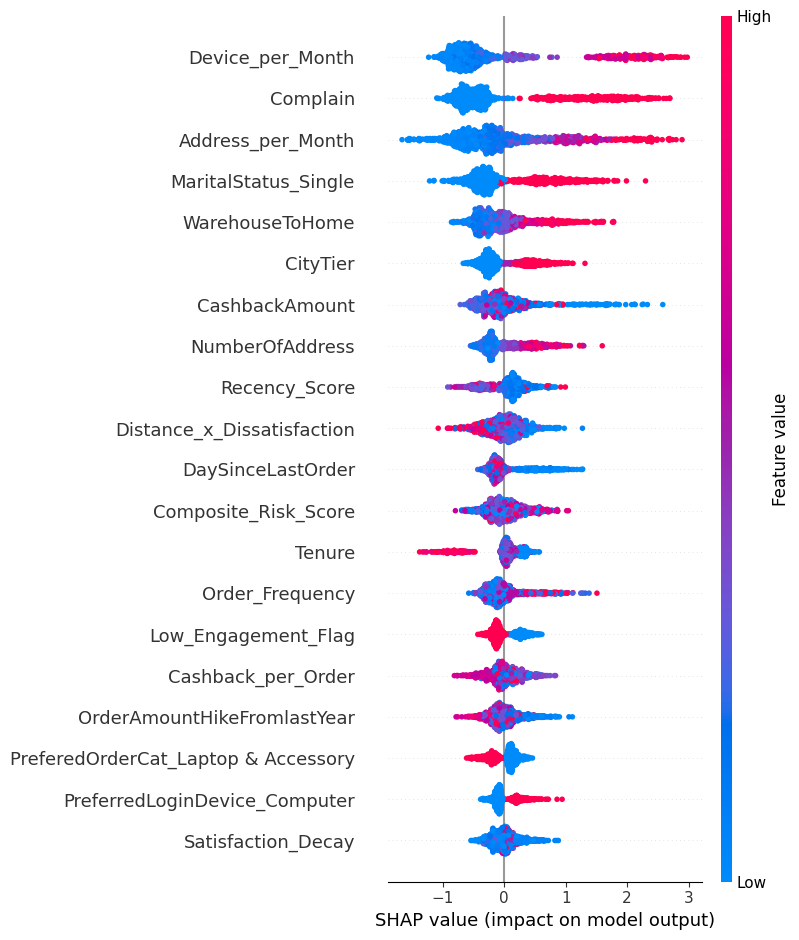

In [77]:
import pandas as pd
import numpy as np
import json
import joblib
import shap

import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report,
    precision_score, recall_score
)

lgbm = lgb.LGBMClassifier(
    objective='binary',
    random_state=42,
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=5,
    min_child_samples=40,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=2
)

param_dist = {
    'n_estimators': [100, 200, 500, 800],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [15, 31, 63, 127],
    'max_depth': [-1, 5, 10, 20],
    'min_child_samples': [10, 20, 30, 50],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_dist,
    n_iter=30,
    scoring='f1',
    cv=skf,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Use leakage-free train split
random_search.fit(_X_train, _y_train)

print("Best Parameters:", random_search.best_params_)
print("Best CV Score:", random_search.best_score_)

best_lgbm_export = random_search.best_estimator_

_y_pred = best_lgbm_export.predict(_X_test)
_y_proba = best_lgbm_export.predict_proba(_X_test)[:, 1]

# Save scored test
scored_test = _X_test.copy()
scored_test["Churn_true"] = _y_test.values
scored_test["Churn_pred"] = _y_pred
scored_test["Churn_probability"] = _y_proba
scored_test.to_csv("lgbm_test_scored.csv", index=False)
print("Saved: lgbm_test_scored.csv")

# SHAP Feature Importance
print("Computing SHAP feature importance...")

explainer = shap.TreeExplainer(best_lgbm_export)
sample_size = min(2000, _X_test.shape[0])
X_shap_sample = _X_test.iloc[:sample_size]
feature_names = _X_test.columns.tolist()

shap_values = explainer.shap_values(X_shap_sample)

if isinstance(shap_values, list):
    shap_values_for_importance = shap_values[1] if len(shap_values) > 1 else shap_values[0]
else:
    shap_values_for_importance = shap_values

shap_importance = np.abs(shap_values_for_importance).mean(axis=0)

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": shap_importance
}).sort_values("importance", ascending=False).reset_index(drop=True)

feature_importance_df.to_csv("feature_importance.csv", index=False)
print("Saved: feature_importance.csv")

display(feature_importance_df.head(25))

# SHAP summary plot
shap.summary_plot(shap_values_for_importance, X_shap_sample, feature_names=feature_names)


In [78]:
# Save model + preprocessing artifacts for Streamlit
import joblib, json

joblib.dump(num_imputer_cls, "lgbm_num_imputer.joblib")
joblib.dump(cat_imputer_cls, "lgbm_cat_imputer.joblib")
joblib.dump(_export_encoder, "lgbm_encoder.joblib")
joblib.dump(_export_scaler, "lgbm_scaler.joblib")
joblib.dump(best_lgbm_export, "lgbm_model.joblib")

meta = {
    "target": "Churn",
    "raw_input_columns": _export_X.columns.tolist(),
    "num_cols": _export_numerical_cols,
    "cat_cols": _export_categorical_cols,
    "metrics": {
        "accuracy": float(accuracy_score(_y_test, _y_pred)),
        "precision": float(precision_score(_y_test, _y_pred, zero_division=0)),
        "recall": float(recall_score(_y_test, _y_pred, zero_division=0)),
        "f1": float(f1_score(_y_test, _y_pred, zero_division=0)),
        "roc_auc": float(roc_auc_score(_y_test, _y_proba))
    }
}

with open("lgbm_metadata.json", "w") as f:
    json.dump(meta, f, indent=2)

print("Saved artifacts:")
print("  - lgbm_num_imputer.joblib")
print("  - lgbm_cat_imputer.joblib")
print("  - lgbm_encoder.joblib")
print("  - lgbm_scaler.joblib")
print("  - lgbm_model.joblib")
print("  - lgbm_metadata.json")


Saved artifacts:
  - lgbm_num_imputer.joblib
  - lgbm_cat_imputer.joblib
  - lgbm_encoder.joblib
  - lgbm_scaler.joblib
  - lgbm_model.joblib
  - lgbm_metadata.json


In [79]:
# Launch Streamlit dashboard
import subprocess, webbrowser, time

proc = subprocess.Popen(
    ["streamlit", "run", "app.py", "--server.headless", "true"],
    stdout=subprocess.PIPE, stderr=subprocess.PIPE
)
time.sleep(3)
print("Streamlit is running at http://localhost:8501")
webbrowser.open("http://localhost:8501")

Streamlit is running at http://localhost:8501


True